<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/SPACEDOS-ISS-RadLab/blob/main/SPACEDOS_ISS_2019_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS02

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from IPython.display import Image as ImageDisp
from pandas import DataFrame
import string
import os
import glob
import matplotlib.pyplot as plt
import matplotlib
import gdown
%matplotlib inline

# SPACEDOS ISS 2019-2020

Launch Soyuz MS-15: 25.09.2019, 13:57:42.701 UTC
- Launch site: Baikonur
- Launch pad: 1
- Altitude: 414 km
- Inclination: 51.6°

### Docking ISS: 25.09.2019, 19:42:40 UTC
### Undocking ISS: 06.02.2020, 05:50:28 UTC

Landing Soyuz MS-13: 06.02.2020, 09:12:23 UTC
- Landing site: 47°26'34.26''N, 69°33'52.26''E



## Flux and Doserate

In [2]:
# Copy data from iss2019.csv to temporary file
file_id = "1-_z_xvM5GsaPYbgcDY2V5N_DckmPfniK"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

'data.csv'

In [3]:
# Read temporary file
rc = pd.read_csv("data.csv", sep=',', header=0, comment='*')#,engine='python' )

rc.reset_index(drop=True, inplace=True)
rc.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,249,250,251,252,253,254,255,256,257,sum
0,250000,NaN,53318,3101377,0,13598.0,7676.0,21.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24703.0,22.0,255.0,1.0
1,250001,NaN,53319,3101390,0,13879.0,7444.0,16.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24659.0,17.0,255.0,1.0
2,250002,NaN,53320,3101403,13844,7473.0,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24663.0,0.0,256.0,0.0
3,250003,NaN,53321,3101416,0,13988.0,7368.0,16.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24627.0,16.0,255.0,0.0
4,250004,NaN,53322,3101429,13738,7542.0,17.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24699.0,3.0,256.0,1.0


Text(0, 0.5, 'Flux [cm$^-$$^2$ s$^-$$^1$]')

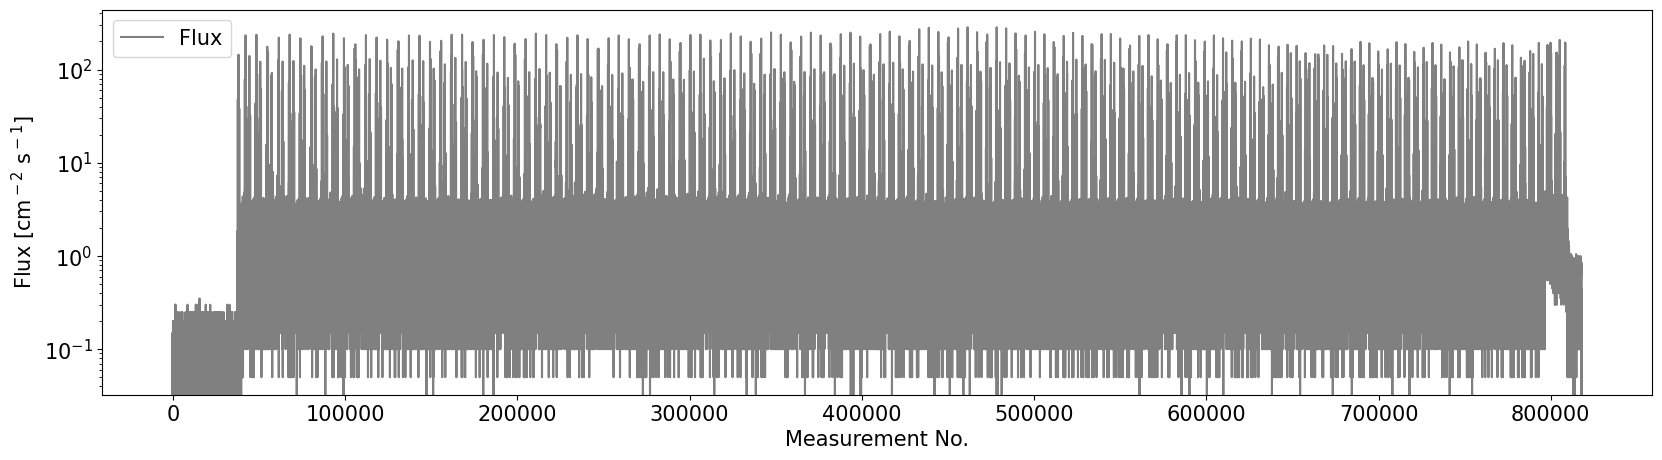

In [4]:
# ensure numbers
rc = rc.apply(pd.to_numeric, errors='coerce')

# mask
mask = rc['257'] == 255

# ––– shift for columns 4..253 only
cols_4_253 = [str(i) for i in range(4, 254)]     # destination
cols_5_254 = [str(i) for i in range(5, 255)]     # zsource

# filter by mask
rc.loc[mask, cols_4_253] = rc.loc[mask, cols_5_254].to_numpy()

# drop columns 0 and 3
rc = rc.drop(columns=[ '0', '3' ], errors='ignore')

# drop columns >= 254
drop_254_plus = [c for c in rc.columns if c.isdigit() and int(c) >= 254]
rc = rc.drop(columns=drop_254_plus, errors='ignore')

# flux
rc['sum'] = rc.loc[:, '6':'253'].sum(axis=1)

# plot
plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

plt.plot(rc['sum']/10/2, c='gray', label='Flux')
plt.yscale('log')
plt.legend()
plt.xlabel('Measurement No.')
plt.ylabel(r'Flux [cm$^-$$^2$ s$^-$$^1$]')


In [5]:
# Monotone time

# ensure numbers
rc['2'] = pd.to_numeric(rc['2'], errors='coerce')

s = rc['2']

# interroe diference
d = s.diff()

# true if difference is negative
reset = d < 0

# cumilative offset
offset = (reset * s.shift(1).fillna(0)).cumsum()

# new cumulative time
rc['time'] = s + offset


In [6]:
import numpy as np
import pandas as pd

# ensure numbers 6..253
cols = [str(i) for i in range(6, 254)]
rc[cols] = rc[cols].apply(pd.to_numeric, errors='coerce')

# energy in keV: 152 keV for '6', +38 keV every next column
energies_keV = 152 + 38 * np.arange(len(cols))

# weighted sum
rc['ener'] = rc[cols].multiply(energies_keV, axis=1).sum(axis=1)


/tmp/ipython-input-1663300696.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rc['ener'] = rc[cols].multiply(energies_keV, axis=1).sum(axis=1)


In [7]:
import numpy as np
import pandas as pd

# ensure numbers
rc['ener'] = pd.to_numeric(rc['ener'], errors='coerce')

# --- physical constants ---
keV_to_J = 1.602176634e-16          # [J/keV]
rho_Si_g_cm3 = 2.33                  # [g/cm^3]
# [mm] -> [mm^3] -> [cm^3]
vol_mm3 = 10 * 20 * 0.25             # = 50 mm^3
vol_cm3 = vol_mm3 / 1000.0           # = 0.05 cm^3
mass_kg = (vol_cm3 * rho_Si_g_cm3) / 1000.0   # 0.05*2.33 g -> kg

window_s = 10.0                      # integration window
# (J/keV) / kg * (3600/10) hod^-1 * 1e6 -> μGy/h / 1 keV
scale_uGy_per_h_per_keV = keV_to_J / mass_kg * (3600.0 / window_s) * 1e6

# ddsi in μGy/h
rc['ddsi'] = rc['ener'] * scale_uGy_per_h_per_keV


/tmp/ipython-input-2577679339.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rc['ddsi'] = rc['ener'] * scale_uGy_per_h_per_keV


In [8]:
rc['time'] = pd.to_numeric(rc['time'], errors='coerce')

# Launch time
ref_seconds = 3_590_187
ref_abs = pd.Timestamp('2019-09-25 13:57:43', tz='UTC')

t0 = ref_abs - pd.to_timedelta(ref_seconds, unit='s')

# time error (multiplicative drift)
k = 1.005  # <-- koeficient škálování času

# constant time shift (in seconds)
t_shift = 0.0   # <-- sem dosaď svůj offset v sekundách (kladný = posun dopředu)

# calculation of absolute time
rc['abs_time'] = (
    ref_abs
    + pd.to_timedelta((rc['time'] - ref_seconds) * k, unit='s')
    + pd.to_timedelta(t_shift, unit='s')
)


/tmp/ipython-input-3327520845.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rc['abs_time'] = (


## Orbital data

In [9]:
# Copy data from iss2019.csv to temporary file
file_id = "1vmYGS4G0kw9tNO4FwsOkSp7u08Oq70R7" # 2019
gdown.download(f"https://drive.google.com/uc?id={file_id}", "orbit.csv", quiet=True)

'orbit.csv'

In [10]:
# Read temporary file
cols = ['UTC', 'B', 'L']
orbit = pd.read_csv("orbit.csv", sep='\t', header=0, usecols=cols)

orbit.reset_index(drop=True, inplace=True)
orbit["UTC"] = pd.to_datetime(orbit["UTC"], unit="s", utc=True)

orbit.head()

,UTC,B,L
0,2019-09-25 13:57:42+00:00,45034.3,1.92800
1,2019-09-25 13:57:43+00:00,45052.2,1.92970
2,2019-09-25 13:57:44+00:00,45070.1,1.93140
3,2019-09-25 13:57:45+00:00,45087.9,1.93309
4,2019-09-25 13:57:46+00:00,45105.8,1.93479


Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

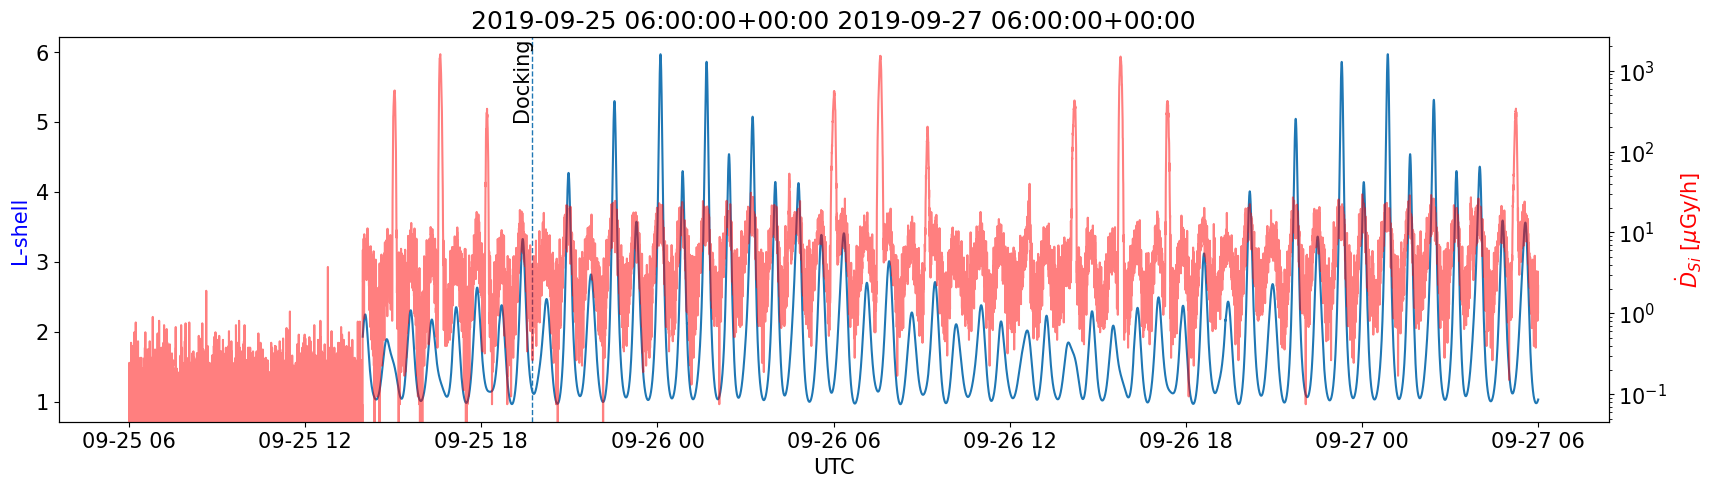

In [11]:
# --- zoom
tmin = pd.Timestamp("2019-09-25 06:00:00", tz="UTC")   # aktuální filtr
#tmin = pd.Timestamp("2019-10-26 00:00:00", tz="UTC")   # aktuální filtr
tmax = tmin + pd.Timedelta(days=2)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")
ax1.axvline(mark_t, linestyle="--", linewidth=1)
ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["abs_time"] < tmax].loc[rc["abs_time"] > tmin]
ax2.plot(zoom_data["abs_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



## Time drift Correction

In [12]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator

def daily_corrections_from_anchors(corrections, tz="UTC"):
    """
    corrections: list of (date_or_timestamp, offset_sec)
                 např. [("2019-09-25", 0), ("2019-10-26", 500), ...]
    tz: časová zóna výsledného indexu (default UTC)
    return: DataFrame se sloupci ["date", "offset_sec"] po jednotlivých dnech
    """
    # --- kotvy ---
    corr = pd.DataFrame(corrections, columns=["date", "offset_sec"])
    corr["date"] = pd.to_datetime(corr["date"], utc=True)
    corr = corr.sort_values("date").reset_index(drop=True)

    # pojistka monotonicity (neklesající)
    corr["offset_sec"] = corr["offset_sec"].cummax()

    # --- denní mřížka ---
    start = corr["date"].min().normalize()
    end   = corr["date"].max().normalize()
    daily_idx = pd.date_range(start=start, end=end, freq="D", tz="UTC")

    # --- PCHIP (monotónní, C¹, shape-preserving) ---
    x = corr["date"].astype("int64").to_numpy()          # ns od epochy
    y = corr["offset_sec"].to_numpy(dtype=float)
    f = PchipInterpolator(x, y, extrapolate=True)

    t = daily_idx.astype("int64").to_numpy()
    daily_offset = f(t)

    out = pd.DataFrame({"date": daily_idx.tz_convert(tz), "offset_sec": daily_offset})
    return out

# ---- corrections ----
corrections = [
    ("2019-09-25", 0),
    ("2019-10-20", 0),
    ("2019-10-22", 0),
    ("2019-10-26", 500),
    ("2019-11-01", 1000),
    ("2019-11-10", 1800),
    ("2019-11-15", 1800),
    ("2019-11-18", 1800),
    ("2019-11-20", 2000),
    ("2019-11-25", 2600),
    ("2019-12-01", 3200),
    ("2019-12-10", 3200),
    ("2019-12-15", 3800),
    ("2019-12-20", 3800),
    ("2020-01-10", 3800),
    ("2020-01-20", 3800),
    ("2020-01-25", 3800),
    ("2020-01-27", 4000),
    ("2020-02-01", 4400),
    ("2020-02-03", 4400),
    ("2020-02-05", 4400),
]

daily_table = daily_corrections_from_anchors(corrections, tz="UTC")
print(daily_table.head(12))       # náhled
# daily_table.to_csv("daily_corrections.csv", index=False)  # volitelně uložení


                        date  offset_sec
0  2019-09-25 00:00:00+00:00         0.0
1  2019-09-26 00:00:00+00:00         0.0
2  2019-09-27 00:00:00+00:00         0.0
3  2019-09-28 00:00:00+00:00         0.0
4  2019-09-29 00:00:00+00:00         0.0
5  2019-09-30 00:00:00+00:00         0.0
6  2019-10-01 00:00:00+00:00         0.0
7  2019-10-02 00:00:00+00:00         0.0
8  2019-10-03 00:00:00+00:00         0.0
9  2019-10-04 00:00:00+00:00         0.0
10 2019-10-05 00:00:00+00:00         0.0
11 2019-10-06 00:00:00+00:00         0.0


In [13]:
# předpoklad:
# rc['abs_time']  ... datetime64[ns, UTC]
# daily_table     ... obsahuje sloupce ["date", "offset_sec"]

# 1) zajisti správné typy a seřazení
rc = rc.sort_values("abs_time")
daily_table = daily_table.sort_values("date")

# 2) merge podle nejbližšího dřívějšího dne (as-of join)
rc = pd.merge_asof(
    rc,
    daily_table.rename(columns={"date": "abs_time"}),   # musí mít stejné jméno klíče
    on="abs_time",
    direction="backward"
)

# 3) spočítat korigovaný čas
rc["corr_time"] = rc["abs_time"] + pd.to_timedelta(rc["offset_sec"], unit="s")


Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

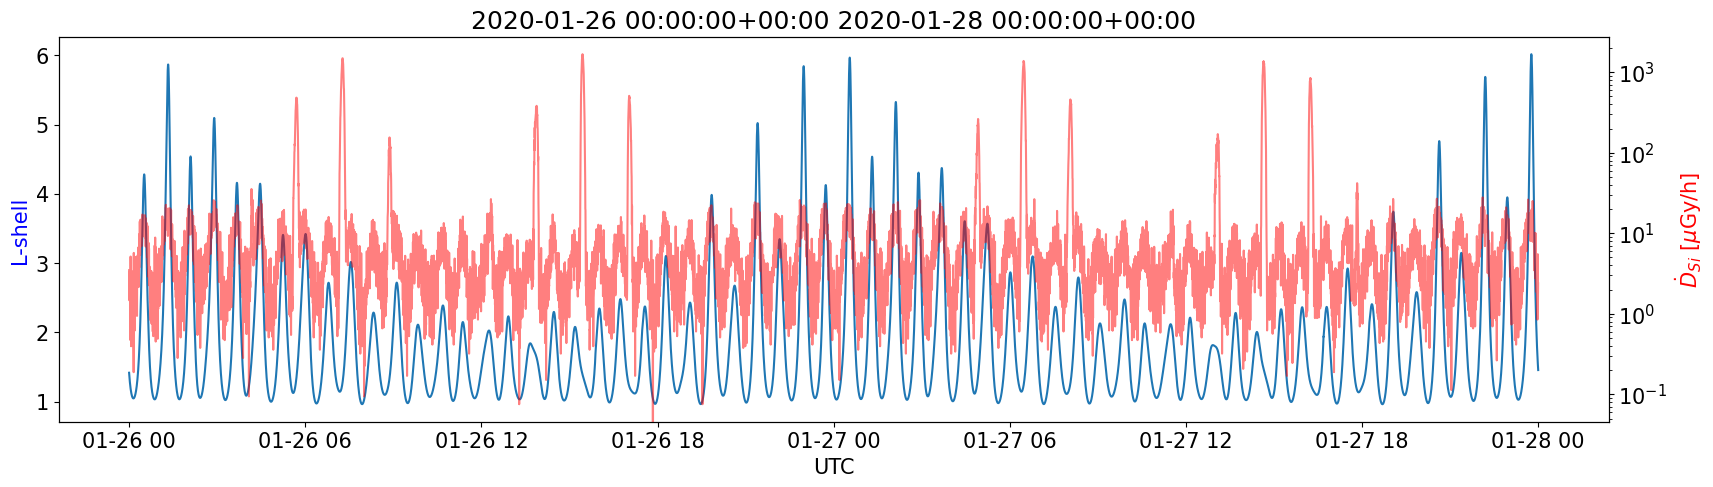

In [14]:
# --- zoom
tmin = pd.Timestamp("2019-09-25 06:00:00", tz="UTC")   # launch
tmin = pd.Timestamp("2019-12-26 00:00:00", tz="UTC")   # 2019
tmin = pd.Timestamp("2020-01-26 00:00:00", tz="UTC")   # 2020
tmax = tmin + pd.Timedelta(days=2)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")
#ax1.axvline(mark_t, linestyle="--", linewidth=1)
#ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
#         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



## Save output to file

In [15]:
ble
output_file = "SPACEDOS_ISS2019_corrected.csv"
rc.to_csv(output_file, index=False)

NameError: name 'ble' is not defined

In [ ]:
rc.iloc[600000]

## Spectrum

In [ ]:
rc

0.105 0.038


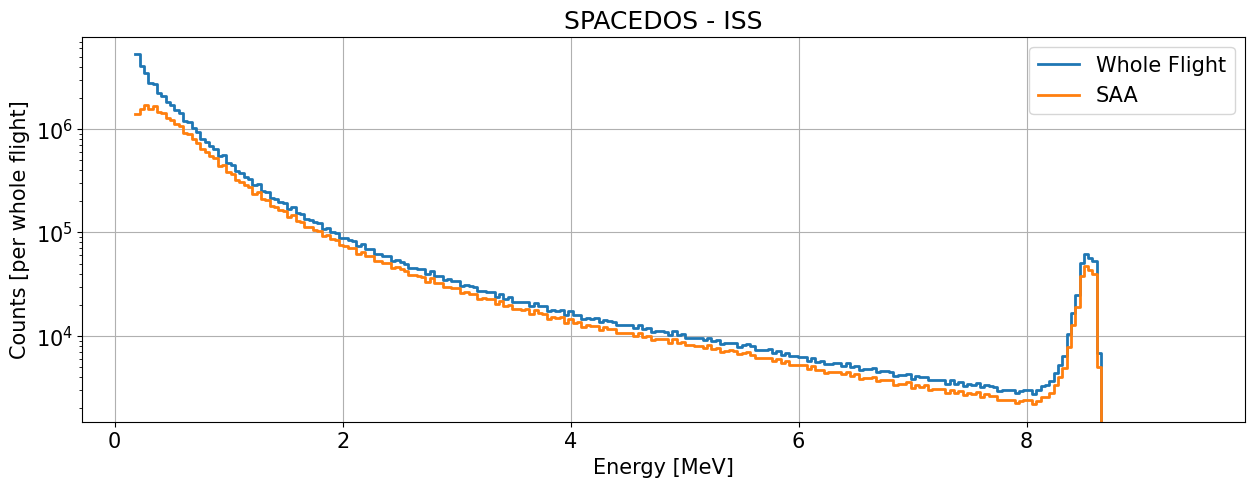

In [16]:
plt.figure(figsize=(15,5))
matplotlib.rcParams.update({'font.size': 15})

LOW_ENERGY = 5
HIGH_ENERGY = 250
CH = 4

ener1 = rc.iloc[:,LOW_ENERGY:HIGH_ENERGY].sum()
ener2 = rc.loc[(rc['sum']>80)].iloc[:,LOW_ENERGY:HIGH_ENERGY].sum() # SAA

coef = np.array([0.,0.])
coef[1] = 0.038
coef[0] = 0.105

print (coef[0], coef[1])

e = pd.DataFrame()
e['1'] = ener1
e['i'] = ener1.index
e['x'] = (e['i'].astype(float)-CH) * coef[1] + coef[0]

plt.yscale('log')

plt.plot(e['x'], e['1'], label='Whole Flight', lw=2, drawstyle='steps-post')

e['1'] = ener2
e['i'] = ener2.index
plt.plot(e['x'], e['1'], label='SAA', lw=2, drawstyle='steps-post')

plt.legend()
plt.title('SPACEDOS - ISS')
plt.xlabel('Energy [MeV]')
plt.ylabel(r'Counts [per whole flight]')
plt.grid()

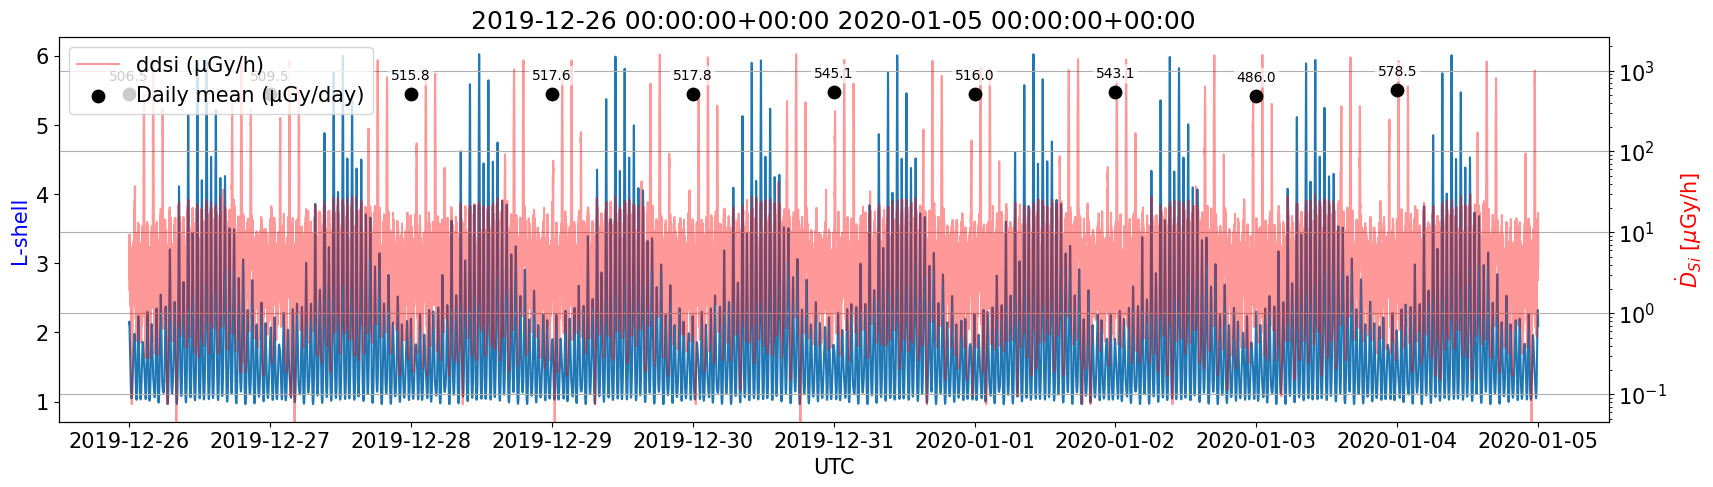

In [17]:
# --- zoom
tmin = pd.Timestamp("2019-12-26 00:00:00", tz="UTC")   # 2019
tmin = pd.Timestamp("2019-12-26 00:00:00", tz="UTC")   # 2019
tmax = tmin + pd.Timedelta(days=10)
zoom = orbit.loc[(orbit["UTC"] > tmin) & (orbit["UTC"] < tmax)]

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")

ax2 = ax1.twinx()
ax2.set_yscale('log')

zoom_data = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)]

# původní průběžná data
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"],
         label="ddsi (µGy/h)", color='red', alpha=0.4)

ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')

# --- denní průměry v µGy/day
daily = zoom_data.set_index("corr_time")["ddsi"].resample("D").mean() * 24.0
ax2.scatter(daily.index, daily, color='black', s=80, zorder=5, label="Daily mean (µGy/day)", marker='o')
ax2.grid()

ax2.legend(loc='upper left')

# popisky hodnot u denních průměrů
daily_clean = daily.dropna()
for x, y in zip(daily_clean.index, daily_clean.values):
    ax2.annotate(f"{y:.1f}", (x, y),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", va="bottom",
                 fontsize=10, color="black",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))



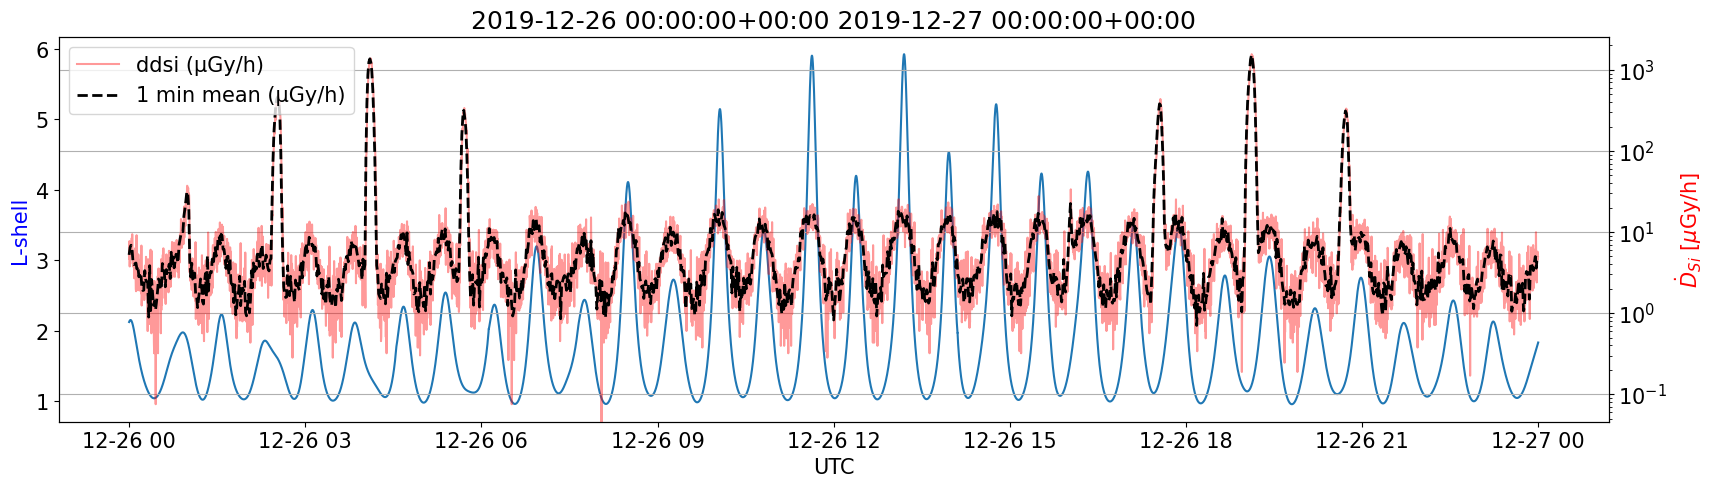

In [22]:
# --- zoom
tmin = pd.Timestamp("2019-12-26 00:00:00", tz="UTC")   # 2019
tmax = tmin + pd.Timedelta(days=1)
zoom = orbit.loc[(orbit["UTC"] > tmin) & (orbit["UTC"] < tmax)]

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")

ax2 = ax1.twinx()
ax2.set_yscale('log')

zoom_data = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)]

# původní průběžná data
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"],
         label="ddsi (µGy/h)", color='red', alpha=0.4)

ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')

# --- 1min resampling (still in µGy/h)
resampled = zoom_data.set_index("corr_time")["ddsi"].resample("1min").mean()

# vykreslení přerušovanou čarou
ax2.plot(resampled.index, resampled,
         label="1 min mean (µGy/h)", color='black', lw=2, linestyle='--')

ax2.grid()
ax2.legend(loc='upper left')
